In [1]:
# Step 1: Imports and settings
import os, glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import exposure
from ipywidgets import interact, IntSlider, Checkbox
from IPython.display import display, clear_output

data_dir = "graphs_stereo"
pattern_size = (11, 8)
square_size = 14.5  # mm

In [4]:
# Step 2: Collect image pairs
left_images = sorted(glob.glob(os.path.join(data_dir, "*_left.png")))
right_images = sorted(glob.glob(os.path.join(data_dir, "*_right.png")))
assert len(left_images) == len(right_images), "Left/right image count mismatch"
num_pairs = len(left_images)
print("Found", num_pairs, "image pairs")

Found 24 image pairs


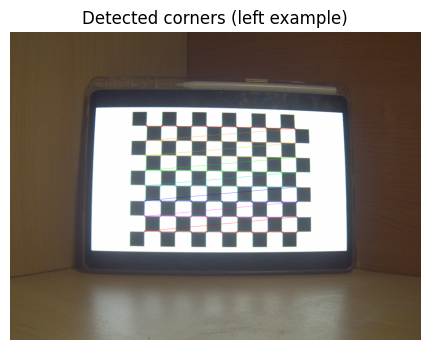

Detected valid pairs: 24


In [5]:
# Step 3: Detect chessboard corners and visualize one example
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
objp = np.zeros((pattern_size[1]*pattern_size[0], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= square_size

objpoints, imgpoints_left, imgpoints_right = [], [], []
example_img = None
for i, (lf, rf) in enumerate(zip(left_images, right_images)):
    imgL = cv2.imread(lf)
    imgR = cv2.imread(rf)
    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
    retL, cornersL = cv2.findChessboardCorners(grayL, pattern_size)
    retR, cornersR = cv2.findChessboardCorners(grayR, pattern_size)
    if retL and retR:
        objpoints.append(objp.copy())
        cornersL = cv2.cornerSubPix(grayL, cornersL, (11,11), (-1,-1), criteria)
        cornersR = cv2.cornerSubPix(grayR, cornersR, (11,11), (-1,-1), criteria)
        imgpoints_left.append(cornersL)
        imgpoints_right.append(cornersR)
        if example_img is None:
            example_img = imgL.copy()
            cv2.drawChessboardCorners(example_img, pattern_size, cornersL, True)

if example_img is not None:
    plt.figure(figsize=(6,4))
    plt.title("Detected corners (left example)")
    plt.imshow(cv2.cvtColor(example_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

print("Detected valid pairs:", len(objpoints))

In [6]:
# Step 4: Single camera calibration
img_shape = cv2.imread(left_images[0]).shape[1::-1]

retL, mtxL, distL, rvecsL, tvecsL = cv2.calibrateCamera(objpoints, imgpoints_left, img_shape, None, None)
retR, mtxR, distR, rvecsR, tvecsR = cv2.calibrateCamera(objpoints, imgpoints_right, img_shape, None, None)

def mean_reproj_error(objpoints, imgpoints, rvecs, tvecs, mtx, dist):
    total_error = 0
    for i in range(len(objpoints)):
        imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
        total_error += cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
    return total_error / len(objpoints)

errL = mean_reproj_error(objpoints, imgpoints_left, rvecsL, tvecsL, mtxL, distL)
errR = mean_reproj_error(objpoints, imgpoints_right, rvecsR, tvecsR, mtxR, distR)

print("Left camera matrix (K):\n", mtxL)
print("Left distortion coeffs:\n", distL.ravel())
print("Left reprojection error:", errL)
print("Right camera matrix (K):\n", mtxR)
print("Right distortion coeffs:\n", distR.ravel())
print("Right reprojection error:", errR)

Left camera matrix (K):
 [[3.70105192e+03 0.00000000e+00 1.20634463e+03]
 [0.00000000e+00 3.70255775e+03 9.97331796e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Left distortion coeffs:
 [-5.39906657e-01 -2.20093148e-01  3.03760632e-04  3.21675416e-03
  3.59199208e+00]
Left reprojection error: 0.047629541946430126
Right camera matrix (K):
 [[3.66664027e+03 0.00000000e+00 1.23451509e+03]
 [0.00000000e+00 3.66841643e+03 9.73886797e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Right distortion coeffs:
 [-5.61094367e-01  1.68985314e-01  1.61088974e-03  1.34425247e-03
  2.80867687e+00]
Right reprojection error: 0.042910420429327974


In [7]:
# Step 5: Stereo calibration (fix intrinsics)
flags = cv2.CALIB_FIX_INTRINSIC
criteria_stereo = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 100, 1e-5)
retStereo, mtxL_s, distL_s, mtxR_s, distR_s, R, T, E, F = cv2.stereoCalibrate(
    objpoints, imgpoints_left, imgpoints_right,
    mtxL, distL, mtxR, distR, img_shape,
    criteria=criteria_stereo, flags=flags
)
print("Stereo calibration RMS error:", retStereo)
print("Rotation R:\n", R)
print("Translation T (vector):\n", T.ravel())

Stereo calibration RMS error: 0.666101343809376
Rotation R:
 [[ 0.99640778  0.00902203  0.08420294]
 [-0.00887498  0.99995837 -0.00212053]
 [-0.08421857  0.00136561  0.99644637]]
Translation T (vector):
 [-71.99955379  -0.17697737   0.36237184]


OpenCV Q (for reference):
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.05899889e+03]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -9.90387070e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  4.03916484e+03]
 [ 0.00000000e+00  0.00000000e+00  1.38887571e-02 -0.00000000e+00]]
Custom Q matrix:
 [[ 1.0000000e+00  0.0000000e+00  0.0000000e+00 -1.0589989e+03]
 [ 0.0000000e+00 -1.0000000e+00  0.0000000e+00  9.9038708e+02]
 [ 0.0000000e+00  0.0000000e+00  4.0391648e+03  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00 -1.3888757e-02  0.0000000e+00]]


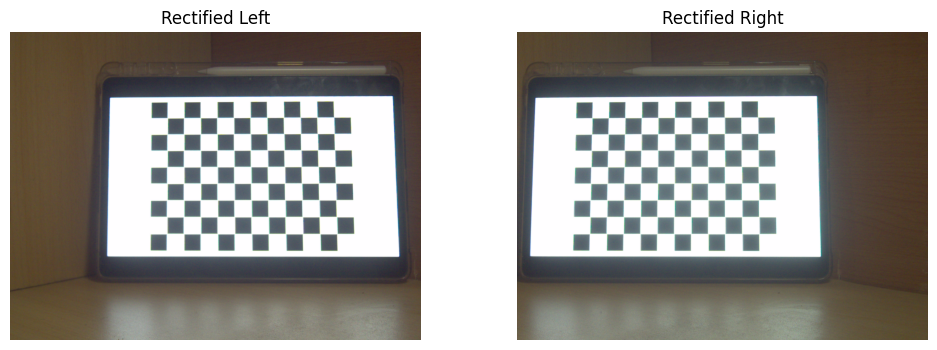

In [8]:
# Step 6: Rectify and construct physically meaningful Q matrix
R1, R2, P1, P2, Q_cv, roi1, roi2 = cv2.stereoRectify(
    mtxL_s, distL_s, mtxR_s, distR_s, img_shape, R, T, alpha=0
)
print("OpenCV Q (for reference):\n", Q_cv)

# Build a Q matrix using baseline and focal length for correct units
baseline = np.linalg.norm(T)  # same units as object points (mm)
f = P1[0,0]
cx = P1[0,2]
cy = P1[1,2]
baseline_safe = baseline if baseline != 0 else 1e-6
Q = np.float32([
    [1, 0, 0, -cx],
    [0, -1, 0, cy],
    [0, 0, f, 0],
    [0, 0, -1.0/baseline_safe, 0]
])
print("Custom Q matrix:\n", Q)

# compute rectification maps and rectify first pair for display and further processing
map1x, map1y = cv2.initUndistortRectifyMap(mtxL_s, distL_s, R1, P1, img_shape, cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(mtxR_s, distR_s, R2, P2, img_shape, cv2.CV_32FC1)
imgL = cv2.imread(left_images[0])
imgR = cv2.imread(right_images[0])
rectL = cv2.remap(imgL, map1x, map1y, cv2.INTER_LINEAR)
rectR = cv2.remap(imgR, map2x, map2y, cv2.INTER_LINEAR)

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].imshow(cv2.cvtColor(rectL, cv2.COLOR_BGR2RGB)); axs[0].set_title("Rectified Left"); axs[0].axis('off')
axs[1].imshow(cv2.cvtColor(rectR, cv2.COLOR_BGR2RGB)); axs[1].set_title("Rectified Right"); axs[1].axis('off')
plt.show()

In [9]:
# Step 7: Interactive disparity explorer (widgets)
grayL = cv2.cvtColor(rectL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(rectR, cv2.COLOR_BGR2GRAY)

def compute_show_disparity(numDisparities=128, blockSize=7, show_edges=False):
    if numDisparities % 16 != 0:
        print("numDisparities must be divisible by 16. Adjusting...")
        numDisparities = (numDisparities // 16) * 16
        if numDisparities == 0:
            numDisparities = 16
    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=numDisparities,
        blockSize=blockSize,
        P1=8*3*blockSize**2,
        P2=32*3*blockSize**2,
        disp12MaxDiff=1,
        uniquenessRatio=10,
        speckleWindowSize=100,
        speckleRange=32
    )
    disp = stereo.compute(grayL, grayR).astype(np.float32) / 16.0
    plt.figure(figsize=(10,4))
    plt.imshow(disp, cmap='plasma')
    plt.colorbar(label='Disparity')
    plt.title(f"Disparity (numDisp={numDisparities}, blockSize={blockSize})")
    plt.axis('off')
    plt.show()
    return disp

disp_widget = interact(compute_show_disparity,
                       numDisparities=IntSlider(value=128, min=16, max=256, step=16),
                       blockSize=IntSlider(value=7, min=3, max=21, step=2),
                       show_edges=Checkbox(value=False))

interactive(children=(IntSlider(value=128, description='numDisparities', max=256, min=16, step=16), IntSlider(…

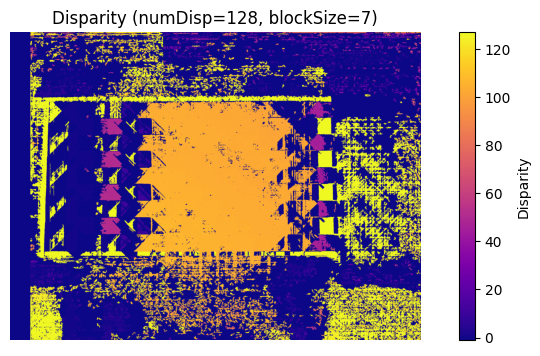

In [15]:
disp = compute_show_disparity(128, 7)